# Import Libraries

In [1]:
import torch
from torchvision import transforms as T
from utils.set_seed import set_random_seed
from torch.utils.tensorboard import SummaryWriter
from weathernet import WeatherNet
from weathernetplusplus import WeatherNetPlusPlus
from mtl_weathernet import MtlWeatherNet
from weathernet_transformer import WeatherNetTransformer

from data.data import get_dataloaders
import utils.trainer as trainer

device = 'cpu'
if torch.backends.mps.is_available(): device = torch.device('mps')
elif torch.cuda.is_available(): device = torch.device('cuda')
print(device)

cuda


# Set Hyperparameters, Load Dataset

In [2]:
batch_size = 16
set_random_seed(42) # seed for reproducibility

In [3]:
# Load BDD100KPlus dataset
trainloader, valloader, testloader = get_dataloaders(dataset_name="Bdd100kPlus", batch_size=batch_size)

## Get Prediction on Image

In [4]:
def get_prediction_labels(model, outputs):
    if model.get_num_pipelines() == 4: # WeatherNet
        fog_out = outputs[:, 0]
        glare_out = outputs[:, 1]
        weather_out = outputs[:, 2:8]
        tod_out = outputs[:, 8:12]

        # Convert raw logits on binary classifiers to categorical labels
        fog_out = fog_out.squeeze() > 0.5
        glare_out = glare_out.squeeze() > 0.5

        # Convert raw logits on multiclass to categorical labels
        weather_out = torch.argmax(weather_out, dim=1)
        tod_out = torch.argmax(tod_out, dim=1)

        evals = torch.tensor([
            fog_out,
            glare_out,
            weather_out,
            tod_out
        ]).to(device=device)

        return evals
    
    elif model.get_num_pipelines() == 7: # WeatherNet++, MtlWeatherNet, WeatherNetTransformer
        fog_out = outputs[:, 0]
        glare_out = outputs[:, 1]
        road_out = outputs[:, 2:5]
        traffic_out = outputs[:, 5:8]
        weather_out = outputs[:, 8:14]
        scene_out = outputs[:, 14:18]
        tod_out = outputs[:, 18:22]

        # Convert raw logits on binary classifiers to categorical labels
        fog_out = fog_out.squeeze() > 0.5
        glare_out = glare_out.squeeze() > 0.5

        # Convert raw logits on multiclass to categorical labels
        road_out = torch.argmax(road_out, dim=1)
        traffic_out = torch.argmax(traffic_out, dim=1)
        weather_out = torch.argmax(weather_out, dim=1)
        scene_out = torch.argmax(scene_out, dim=1)
        tod_out = torch.argmax(tod_out, dim=1)

        evals = torch.tensor([
            fog_out,
            glare_out,
            road_out,
            traffic_out,
            weather_out,
            scene_out,
            tod_out
        ]).to(device=device)

        return evals

## Confusion Matrices

In [37]:
import sklearn.metrics as metrics

def create_confusion_matrix(model, dataloader, device):
    model.eval()
    model.to(device)
    with torch.no_grad():
        fog_labels = []
        fog_preds = []

        glare_labels = []
        glare_preds = []

        weather_labels = []
        weather_preds = []

        tod_labels = []
        tod_preds = []

        if model.get_num_pipelines() == 7:
            road_labels = []
            road_preds = []

            scene_labels = []
            scene_preds = []

            traffic_labels = []
            traffic_preds = []

        for i in range(len(dataloader.dataset)):
            # Get image and labels
            image, pipeline_labels = dataloader.dataset.__getitem__(i)

            # Get predicted tensor
            image = image.to(device)
            pipeline_labels = pipeline_labels.to(device)
            outputs = model(image.unsqueeze(0))
            evals = get_prediction_labels(model, outputs)

            labels = pipeline_labels
            pred_labels = evals

            if model.get_num_pipelines() == 4:
                fog_labels.append(labels[0])
                fog_preds.append(pred_labels[0])

                glare_labels.append(labels[1])
                glare_preds.append(pred_labels[1])

                weather_labels.append(labels[4])
                weather_preds.append(pred_labels[2])

                tod_labels.append(labels[6])
                tod_preds.append(pred_labels[3])

            elif model.get_num_pipelines() == 7:
                fog_labels.append(labels[0])
                fog_preds.append(pred_labels[0])

                glare_labels.append(labels[1])
                glare_preds.append(pred_labels[1])

                road_labels.append(labels[2])
                road_preds.append(pred_labels[2])

                traffic_labels.append(labels[3])
                traffic_preds.append(pred_labels[3])

                weather_labels.append(labels[4])
                weather_preds.append(pred_labels[4])

                scene_labels.append(labels[5])
                scene_preds.append(pred_labels[5])

                tod_labels.append(labels[6])
                tod_preds.append(pred_labels[6])

        # Create confusion matrix
        fog_labels = torch.stack(fog_labels).cpu().numpy()
        fog_preds = torch.stack(fog_preds).cpu().numpy()

        glare_labels = torch.stack(glare_labels).cpu().numpy()
        glare_preds = torch.stack(glare_preds).cpu().numpy()

        weather_labels = torch.stack(weather_labels).cpu().numpy()
        weather_preds = torch.stack(weather_preds).cpu().numpy()

        tod_labels = torch.stack(tod_labels).cpu().numpy()
        tod_preds = torch.stack(tod_preds).cpu().numpy()

        cm_fog = metrics.confusion_matrix(fog_labels, fog_preds)
        cm_fog_pct = metrics.confusion_matrix(fog_labels, fog_preds, normalize='true') * 100

        cm_glare = metrics.confusion_matrix(glare_labels, glare_preds)
        cm_glare_pct = metrics.confusion_matrix(glare_labels, glare_preds, normalize='true') * 100

        cm_weather = metrics.confusion_matrix(weather_labels, weather_preds)
        cm_weather_pct = metrics.confusion_matrix(weather_labels, weather_preds, normalize='true') * 100

        cm_tod = metrics.confusion_matrix(tod_labels, tod_preds)
        cm_tod_pct = metrics.confusion_matrix(tod_labels, tod_preds, normalize='true') * 100

        if model.get_num_pipelines() == 7:
            road_labels = torch.stack(road_labels).cpu().numpy()
            road_preds = torch.stack(road_preds).cpu().numpy()

            traffic_labels = torch.stack(traffic_labels).cpu().numpy()
            traffic_preds = torch.stack(traffic_preds).cpu().numpy()

            scene_labels = torch.stack(scene_labels).cpu().numpy()
            scene_preds = torch.stack(scene_preds).cpu().numpy()

            cm_road = metrics.confusion_matrix(road_labels, road_preds)
            cm_road_pct = metrics.confusion_matrix(road_labels, road_preds, normalize='true') * 100
            
            cm_traffic = metrics.confusion_matrix(traffic_labels, traffic_preds)
            cm_traffic_pct = metrics.confusion_matrix(traffic_labels, traffic_preds, normalize='true') * 100

            cm_scene = metrics.confusion_matrix(scene_labels, scene_preds)
            cm_scene_pct = metrics.confusion_matrix(scene_labels, scene_preds, normalize='true') * 100

            return [(cm_fog, cm_fog_pct), 
                    (cm_glare, cm_glare_pct), 
                    (cm_weather, cm_weather_pct), 
                    (cm_tod, cm_tod_pct), 
                    (cm_road, cm_road_pct), 
                    (cm_traffic, cm_traffic_pct), 
                    (cm_scene, cm_scene_pct)]
        else:
            return [(cm_fog, cm_fog_pct),
                    (cm_glare, cm_glare_pct), 
                    (cm_weather, cm_weather_pct), 
                    (cm_tod, cm_tod_pct)]

In [38]:
import itertools

def annotate_confusion_matrix(ax, cm, cm_pct):
    # Annotate confusion matrix with labels and percentages
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f'{cm[i, j]}\n ({cm_pct[i, j]:.1f}%)', ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)

Loading saved state from ./checkpoints/weathernet_8.pth


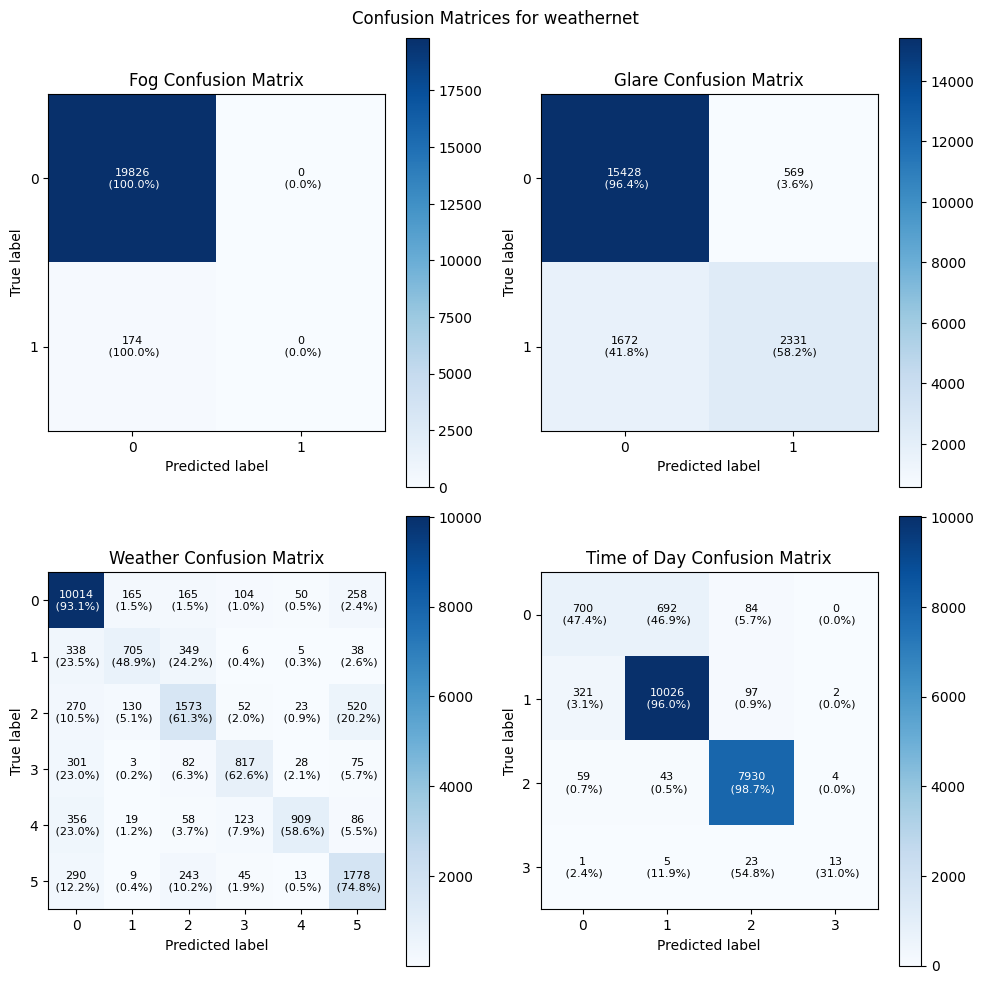

Loading saved state from ./checkpoints/weathernetpp_9.pth


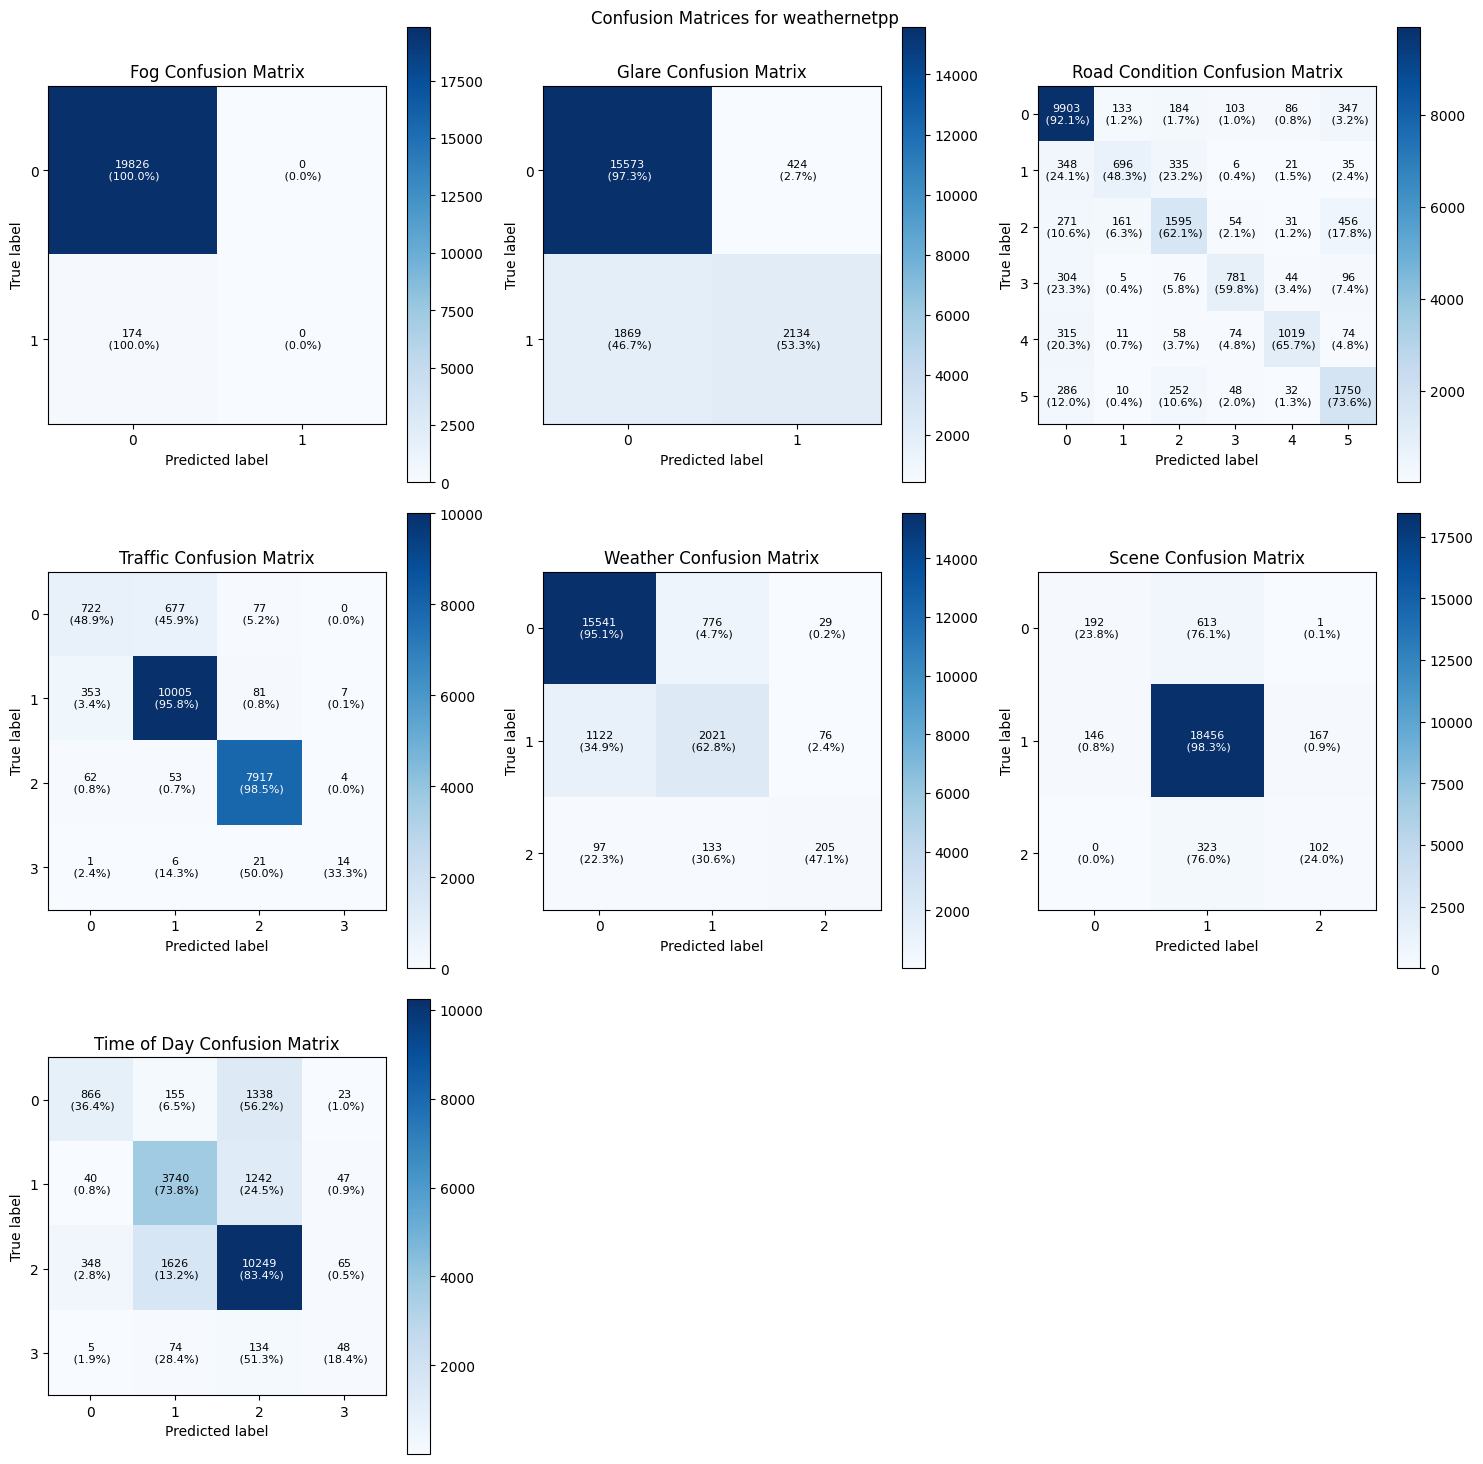

Loading saved state from ./checkpoints/mtl_20.pth


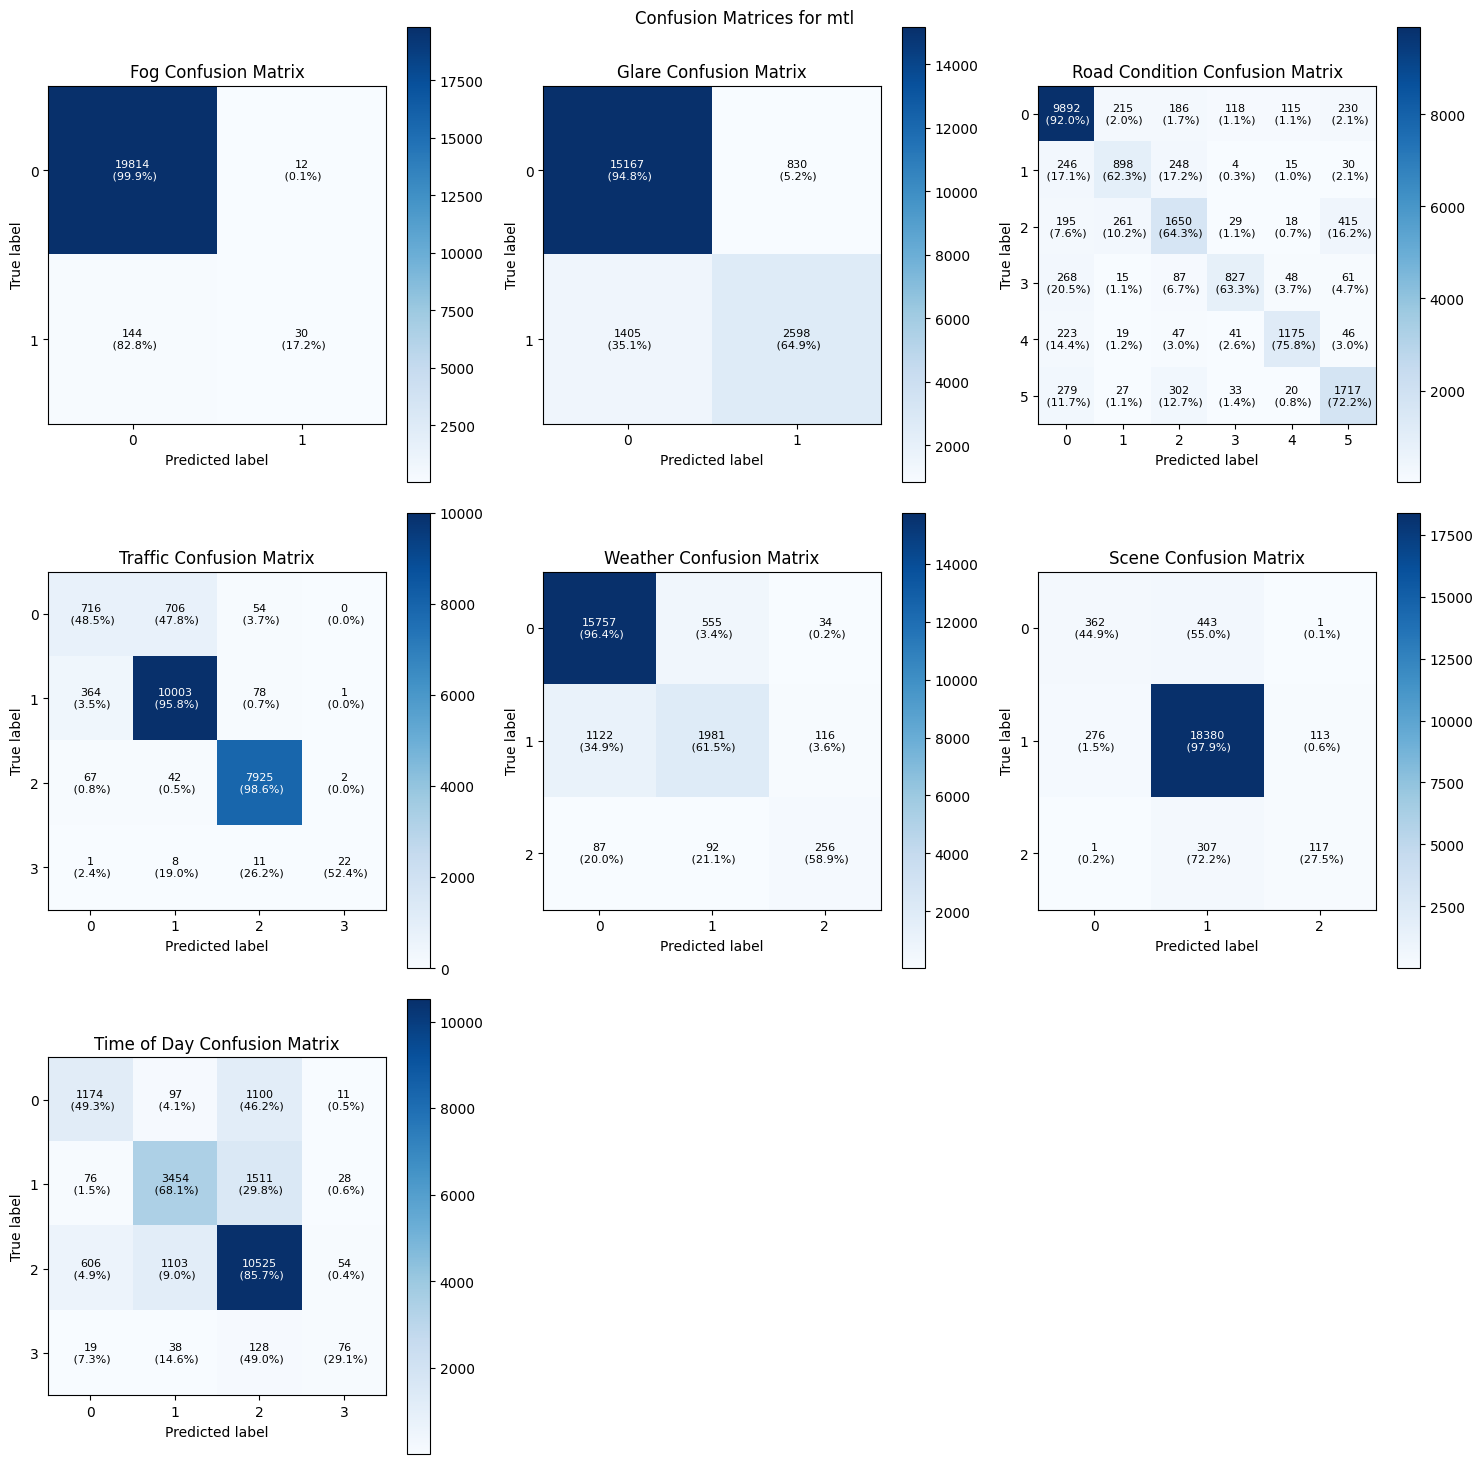

Loading saved state from ./checkpoints/transformer_20.pth


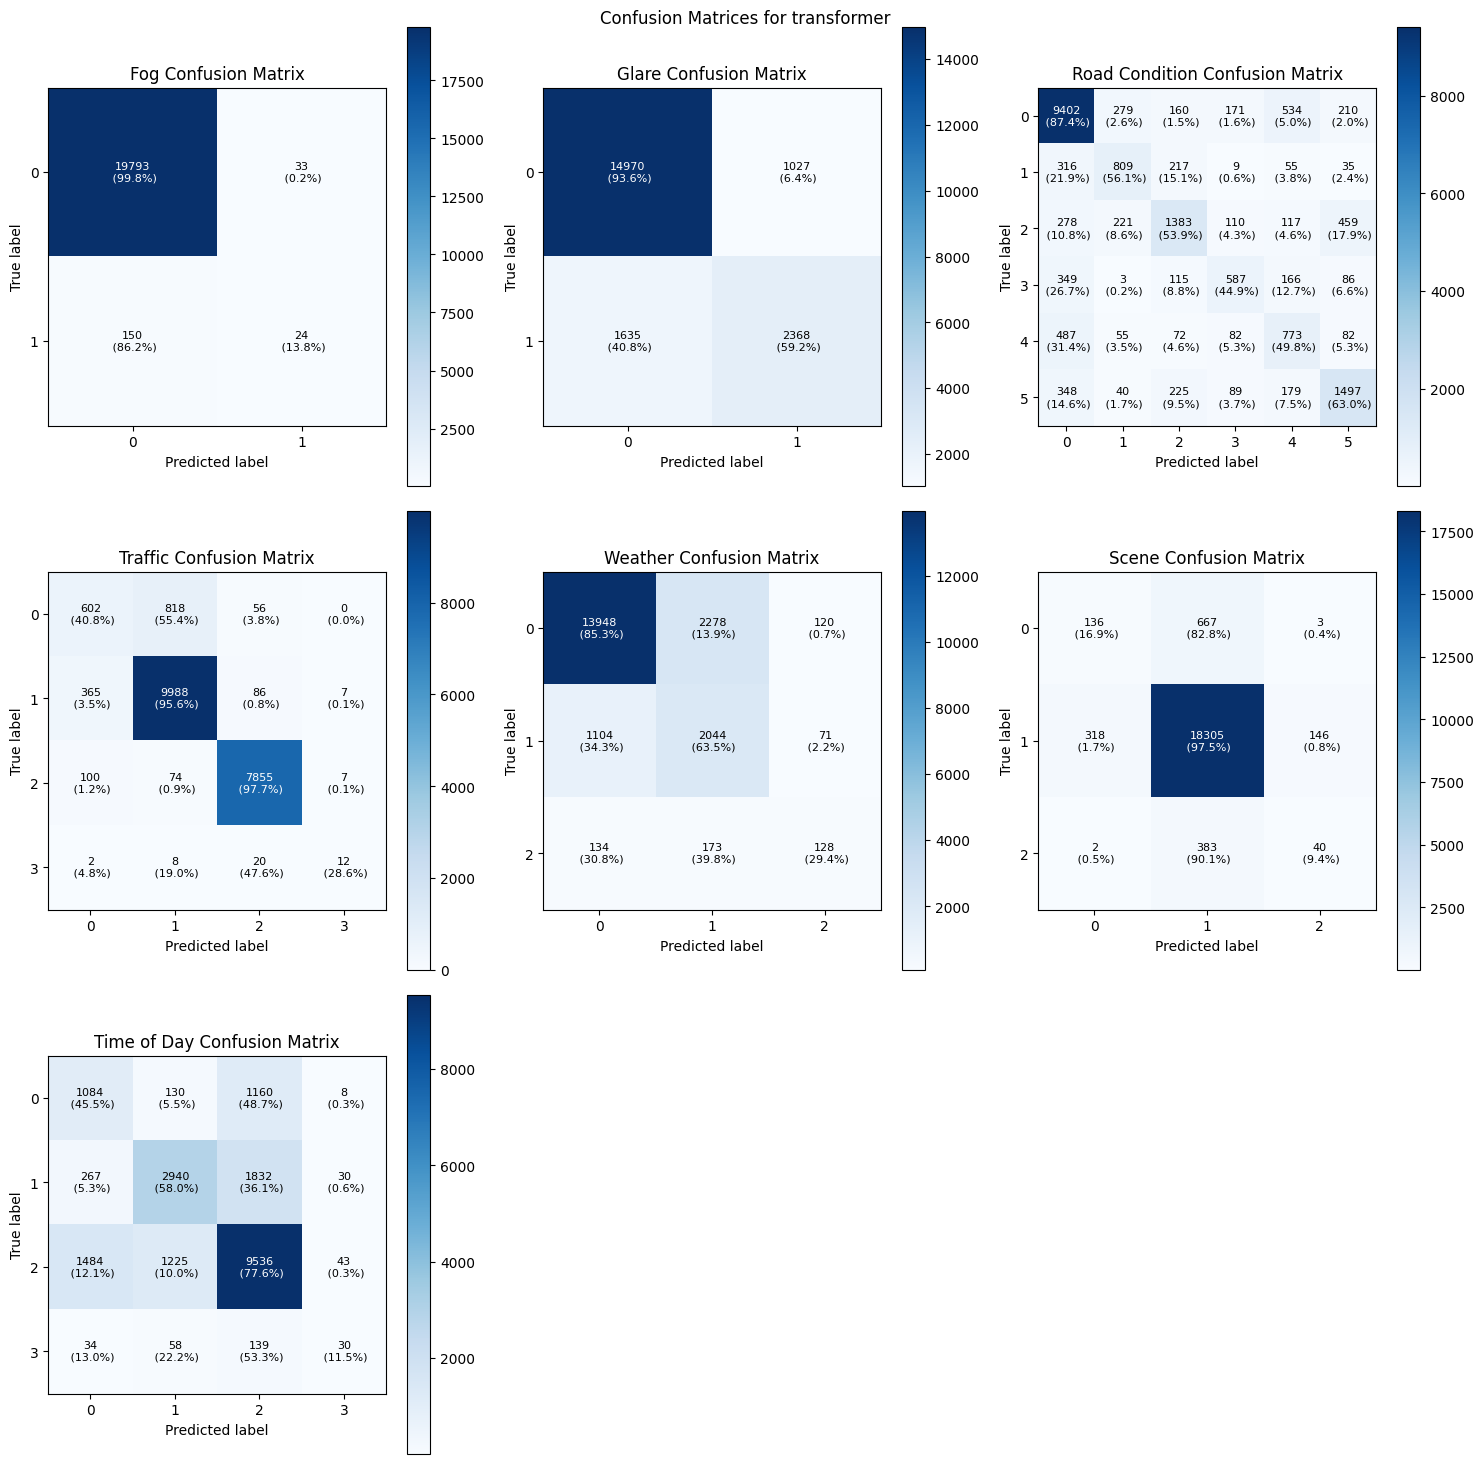

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for model_name in ['weathernet', 'weathernetpp', 'mtl', 'transformer']:
    if model_name == "weathernet":
        checkpoint = 8
        model = WeatherNet()
    elif model_name == "weathernetpp":
        checkpoint = 9
        model = WeatherNetPlusPlus()
    elif model_name == "mtl":
        checkpoint = 20
        model = MtlWeatherNet()
    elif model_name == "transformer":
        checkpoint = 20
        model = WeatherNetTransformer()

    saved_state = f"./checkpoints/{model_name}_{checkpoint}.pth"
    if saved_state is not None:
        print(f"Loading saved state from {saved_state}")
        model.load_checkpoint(saved_state)
        
    cm_list = create_confusion_matrix(model, testloader, device)

    if len(cm_list) == 4: # WeatherNet
        cm_fog, cm_glare, cm_weather, cm_tod = cm_list

        # Create subplots for confusion matrices
        fig, axs = plt.subplots(2, 2, figsize=(10, 10))
        fig.suptitle(f"Confusion Matrices for {model_name}")

        # Plot confusion matrix for fog
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_fog[0])
        disp.plot(ax=axs[0, 0], cmap=plt.cm.Blues, include_values=False)
        axs[0, 0].set_title("Fog Confusion Matrix")
        annotate_confusion_matrix(axs[0, 0], cm_fog[0], cm_fog[1])

        # Plot confusion matrix for glare
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_glare[0])
        disp.plot(ax=axs[0, 1], cmap=plt.cm.Blues, include_values=False)
        axs[0, 1].set_title("Glare Confusion Matrix")
        annotate_confusion_matrix(axs[0, 1], cm_glare[0], cm_glare[1])

        # Plot confusion matrix for weather
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_weather[0])
        disp.plot(ax=axs[1, 0], cmap=plt.cm.Blues, include_values=False)
        axs[1, 0].set_title("Weather Confusion Matrix")
        annotate_confusion_matrix(axs[1, 0], cm_weather[0], cm_weather[1])

        # Plot confusion matrix for time of day
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_tod[0])
        disp.plot(ax=axs[1, 1], cmap=plt.cm.Blues, include_values=False)
        axs[1, 1].set_title("Time of Day Confusion Matrix")
        annotate_confusion_matrix(axs[1, 1], cm_tod[0], cm_tod[1])

        plt.tight_layout()
        plt.show()

    elif len(cm_list) == 7: # WeatherNet++, MtlWeatherNet, WeatherNetTransformer
        cm_fog, cm_glare, cm_road, cm_traffic, cm_weather, cm_scene, cm_tod = cm_list

        # Create subplots for confusion matrices
        fig, axs = plt.subplots(3, 3, figsize=(15, 15))
        fig.suptitle(f"Confusion Matrices for {model_name}")

        # Plot confusion matrix for fog
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_fog[0])
        disp.plot(ax=axs[0, 0], cmap=plt.cm.Blues, include_values=False)
        axs[0, 0].set_title("Fog Confusion Matrix")
        annotate_confusion_matrix(axs[0, 0], cm_fog[0], cm_fog[1])

        # Plot confusion matrix for glare
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_glare[0])
        disp.plot(ax=axs[0, 1], cmap=plt.cm.Blues, include_values=False)
        axs[0, 1].set_title("Glare Confusion Matrix")
        annotate_confusion_matrix(axs[0, 1], cm_glare[0], cm_glare[1])

        # Plot confusion matrix for road
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_road[0])
        disp.plot(ax=axs[0, 2], cmap=plt.cm.Blues, include_values=False)
        axs[0, 2].set_title("Road Condition Confusion Matrix")
        annotate_confusion_matrix(axs[0, 2], cm_road[0], cm_road[1])

        # Plot confusion matrix for traffic
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_traffic[0])
        disp.plot(ax=axs[1, 0], cmap=plt.cm.Blues, include_values=False)
        axs[1, 0].set_title("Traffic Confusion Matrix")
        annotate_confusion_matrix(axs[1, 0], cm_traffic[0], cm_traffic[1])

        # Plot confusion matrix for weather
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_weather[0])
        disp.plot(ax=axs[1, 1], cmap=plt.cm.Blues, include_values=False)
        axs[1, 1].set_title("Weather Confusion Matrix")
        annotate_confusion_matrix(axs[1, 1], cm_weather[0], cm_weather[1])

        # Plot confusion matrix for scene
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_scene[0])
        disp.plot(ax=axs[1, 2], cmap=plt.cm.Blues, include_values=False)
        axs[1, 2].set_title("Scene Confusion Matrix")
        annotate_confusion_matrix(axs[1, 2], cm_scene[0], cm_scene[1])

        # Plot confusion matrix for time of day
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_tod[0])
        disp.plot(ax=axs[2, 0], cmap=plt.cm.Blues, include_values=False)
        axs[2, 0].set_title("Time of Day Confusion Matrix")
        annotate_confusion_matrix(axs[2, 0], cm_tod[0], cm_tod[1])

        axs[2, 1].axis('off')
        axs[2, 2].axis('off')

        plt.tight_layout()
        plt.show()

